In [ ]:
import sys
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join(os.pardir, "src")))
from data_loader import image_downloader
from image_lenet import ListingsDataset
from image_lenet import LeNet5

In [2]:
#load the dataset and save image urls and listings ids in a dictionary
#DONT RUN THIS UNLESS YOU WANT TO DOWNLOAD ALL IMAGES IT TAKES A LONG TIME
df = pd.read_csv("../data/listings.csv")
id_image_dicct = {}
for index, row in df.iterrows():
    if pd.notna(row["picture_url"]):
        id_image_dicct[row["id"]] = row["picture_url"]
print(f"Total images to download: {len(id_image_dicct)}")
#download images
#for listing_id, image_url in id_image_dicct.items():
#    image_downloader(image_url, listing_id, True)

Total images to download: 6481


In [ ]:
# set up transforms and dataloader
transform = transforms.Compose([
    transforms.ToTensor(),
    # Add normalization if needed
])

dataset = ListingsDataset(csv_file="../data/listings.csv", img_dir="../data/image_per_listing", transform=transform)
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [4]:
# Define device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
model = LeNet5().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, prices in train_loader:
        images = images.to(device)
        prices = prices.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, prices)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 225243.5998
Epoch 2/10, Loss: 218813.1427
Epoch 3/10, Loss: 218039.8225
Epoch 4/10, Loss: 218011.1655
Epoch 5/10, Loss: 217946.8301
Epoch 6/10, Loss: 217753.3566
Epoch 7/10, Loss: 218093.2714
Epoch 8/10, Loss: 216883.3403
Epoch 9/10, Loss: 216914.3765
Epoch 10/10, Loss: 216305.8119


In [6]:
# Get a sample from the validation set
val_img, val_price = val_dataset[0]
val_img = val_img.unsqueeze(0).to(device)  # Add batch dimension and move to device

model.eval()
with torch.no_grad():
    pred_price = model(val_img)
    print(f"Predicted price: {pred_price.item():.2f}, Actual price: {val_price:.2f}")

Predicted price: 373.48, Actual price: 49.00


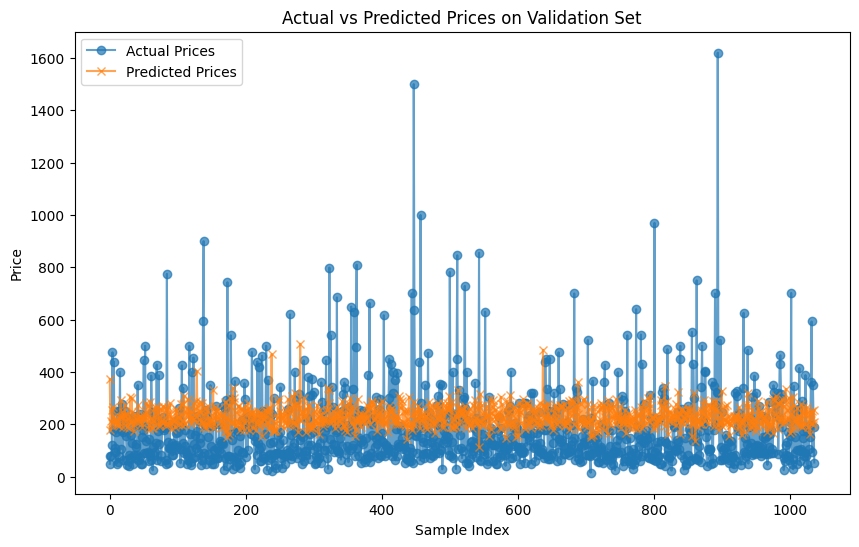

In [ ]:
# plot all predictions vs actual prices on the validation set
model.eval()
predicted_prices = []
actual_prices = []

with torch.no_grad():
    for images, prices in val_loader:
        images = images.to(device)
        prices = prices.float().unsqueeze(1).to(device)
        outputs = model(images)
        predicted_prices.extend(outputs.cpu().numpy().flatten())
        actual_prices.extend(prices.cpu().numpy().flatten())

plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Prices', marker='o', linestyle='-', alpha=0.7)
plt.plot(predicted_prices, label='Predicted Prices', marker='x', linestyle='-', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices on Validation Set')
plt.legend()
plt.show()